In [64]:
import sys
import time
import warnings


# Redirect stderr to a black hole to catch other potential messages
class BlackHole:
    def write(self, message):
        pass

    def flush(self):
        pass


sys.stderr = BlackHole()

# Ignore Python-level UserWarnings
warnings.filterwarnings("ignore", category=UserWarning)

In [65]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import schedulers_helper_utils

schedulers_helper_utils.set_seed(42)

In [66]:
# # Check device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


### a deeper dive into the training process

In [67]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 8 * 8, 64)
        self.fc2 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def train_and_evaluate(learning_rate, device, n_epochs=10, batch_size=32, p_bar=None):

    schedulers_helper_utils.set_seed(42)
    model =  SimpleCNN().to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    loss_fn = nn.CrossEntropyLoss()

    train_loader, val_loader = schedulers_helper_utils.get_dataset_dataloaders(batch_size=batch_size)

    history = schedulers_helper_utils.train_model(
        model=model,
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        optimizer=optimizer,
        loss_fcn=loss_fn,
        p_bar=p_bar,
        n_epochs=n_epochs,
        device=device
    )

    return history

In [68]:
learning_rates = [0.0002, 0.001, 0.005]
training_curves = []
n_epochs = 15
batch_size = 32

p_bar = schedulers_helper_utils.get_p_bar(n_epochs=n_epochs)

num_learning_rates = len(learning_rates)

for i, lr in enumerate(learning_rates):
    print(f"Training with learning rate: {lr}")
    history = train_and_evaluate(learning_rate=lr, device=device, n_epochs=n_epochs, batch_size=batch_size, p_bar=p_bar)
    training_curves.append(history)
    if i < num_learning_rates - 1:
        p_bar.reset()

Training with learning rate: 0.0002
At epoch 5: Training loss: 1.6070, Training accuracy: 0.4049
At epoch 5: Validation loss: 1.5099, Validation accuracy: 0.4630
At epoch 10: Training loss: 1.4350, Training accuracy: 0.4745
At epoch 10: Validation loss: 1.3950, Validation accuracy: 0.5030
At epoch 15: Training loss: 1.3330, Training accuracy: 0.5184
At epoch 15: Validation loss: 1.3390, Validation accuracy: 0.5285
Training complete

Training with learning rate: 0.001
At epoch 5: Training loss: 1.3713, Training accuracy: 0.4970
At epoch 5: Validation loss: 1.3173, Validation accuracy: 0.5240
At epoch 10: Training loss: 1.1176, Training accuracy: 0.5867
At epoch 10: Validation loss: 1.1645, Validation accuracy: 0.5810
At epoch 15: Training loss: 0.9186, Training accuracy: 0.6542
At epoch 15: Validation loss: 1.1417, Validation accuracy: 0.6100
Training complete

Training with learning rate: 0.005
At epoch 5: Training loss: 1.4659, Training accuracy: 0.4551
At epoch 5: Validation loss: 1.

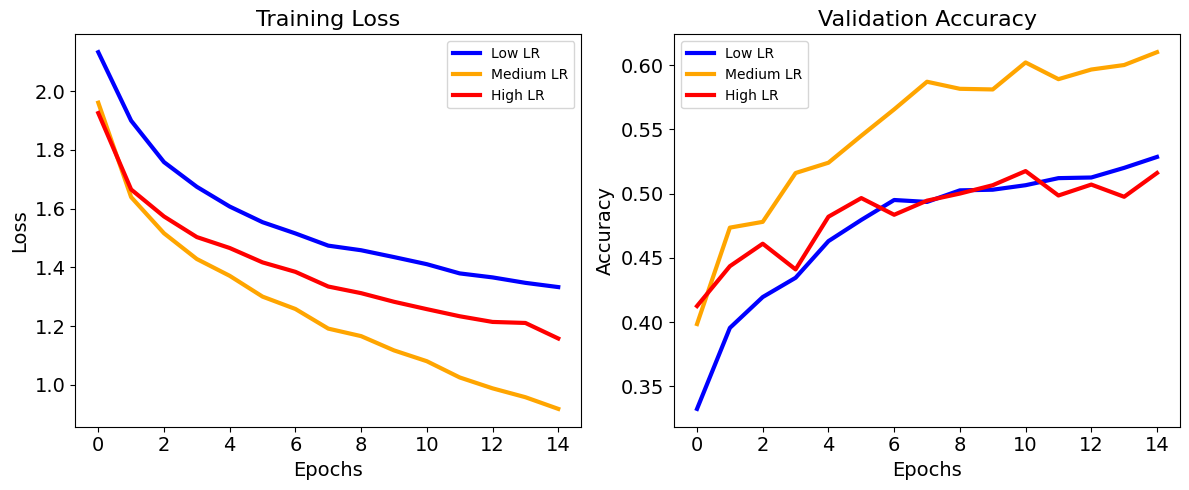

In [76]:
colors = ['blue', 'orange', 'red']
labels = ['Low LR', 'Medium LR', 'High LR']

schedulers_helper_utils.plot_learning_curves(colors, labels, training_curves)

### schedulers

In [75]:
schedulers_helper_utils.set_seed(42)

# Initialize the model, optimizer, loss function, and dataloaders
model = SimpleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005) # start with a high learning rate

In [80]:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=6, gamma=0.8) # reduce the learning rate by 20% it's prior value

In [81]:
loss_fn = nn.CrossEntropyLoss()

train_loader, val_loader = schedulers_helper_utils.get_dataset_dataloaders(batch_size=batch_size)

history_LR = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "lr": []
}

pbar = schedulers_helper_utils.NestedProgressBar(
    total_epochs=n_epochs,
    total_batches=len(train_loader),
    epoch_message_freq=5,
    mode="train",
)
for epoch in range(n_epochs):
    pbar.update_epoch(epoch+1)

    # Train the model for one epoch
    train_loss, train_acc = schedulers_helper_utils.train_epoch(model, train_loader, optimizer, loss_fn, device, pbar)

    # Evaluate the model on the validation set
    val_loss, val_acc = schedulers_helper_utils.evaluate_epoch(model, val_loader, loss_fn, device)

    # Get the current learning rate BEFORE stepping the scheduler.
    # This captures the LR that was just used for the training epoch above.
    current_lr = scheduler.get_last_lr()[0]

    # Step the scheduler (updates the LR for the NEXT epoch)
    scheduler.step()

    pbar.maybe_log_epoch(epoch=epoch+1, message=f"At epoch {epoch+1}: Training loss: {train_loss:.4f}, Training accuracy: {train_acc:.4f}, LR: {current_lr:.6f}")

    pbar.maybe_log_epoch(epoch=epoch+1, message=f"At epoch {epoch+1}: Validation loss: {val_loss:.4f}, Validation accuracy: {val_acc:.4f}")

    history_LR["train_loss"].append(train_loss)
    history_LR["train_acc"].append(train_acc)
    history_LR["val_loss"].append(val_loss)
    history_LR["val_acc"].append(val_acc)
    history_LR["lr"].append(current_lr)

pbar.close('Training complete with StepLR scheduler')

At epoch 5: Training loss: 1.2890, Training accuracy: 0.5258, LR: 0.005000
At epoch 5: Validation loss: 1.3135, Validation accuracy: 0.5300
At epoch 10: Training loss: 1.1023, Training accuracy: 0.5821, LR: 0.004000
At epoch 10: Validation loss: 1.3266, Validation accuracy: 0.5345
At epoch 15: Training loss: 0.9422, Training accuracy: 0.6338, LR: 0.003200
At epoch 15: Validation loss: 1.4312, Validation accuracy: 0.5425
Training complete with StepLR scheduler


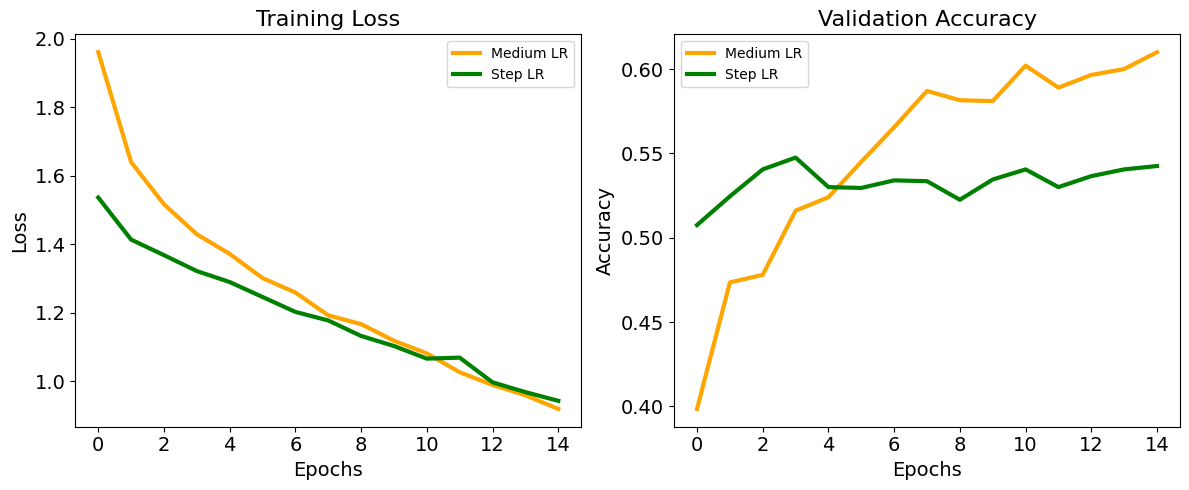

In [82]:
idx = 1
history_constant = training_curves[idx]

colors = ['orange', 'green']
labels =    ['Medium LR', 'Step LR']
histories = [history_constant, history_LR]

schedulers_helper_utils.plot_learning_curves(colors, labels, histories)

In [83]:
def train_and_evaluate_with_scheduler(model, optimizer, scheduler, device, n_epochs=25, batch_size=128):
    """Trains and evaluates a model using a learning rate scheduler.

    Args:
        model: The neural network model to be trained.
        optimizer: The optimization algorithm.
        scheduler: The learning rate scheduler.
        device: The computing device ('cuda' or 'cpu') to run the training on.
        n_epochs: The total number of training epochs.
        batch_size: The number of samples per batch in the data loaders.

    Returns:
        A dictionary containing the training and validation history
        (loss, accuracy, and learning rate) for each epoch.
    """
    # Set the random seed for reproducibility
    schedulers_helper_utils.set_seed(10)

    # Define the loss function
    loss_fn = nn.CrossEntropyLoss()
    # Prepare the training and validation data loaders
    train_loader, val_loader = schedulers_helper_utils.get_dataset_dataloaders(
        batch_size=batch_size
    )

    # Initialize a dictionary to store training and validation history
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        'lr': [],
    }

    # Initialize the progress bar for monitoring training
    pbar = schedulers_helper_utils.NestedProgressBar(
        total_epochs=n_epochs,
        total_batches=len(train_loader),
        epoch_message_freq=5,
        mode="train",
    )

    # Loop through the specified number of epochs
    for epoch in range(n_epochs):

        # Update the progress bar for the current epoch
        pbar.update_epoch(epoch+1)

        # Train the model for one epoch
        train_loss, train_acc = schedulers_helper_utils.train_epoch(model, train_loader, optimizer, loss_fn, device, pbar)
        # Evaluate the model on the validation set
        val_loss, val_acc = schedulers_helper_utils.evaluate_epoch(model, val_loader, loss_fn, device)

        # Retrieve the current learning rate from the scheduler
        current_lr = scheduler.get_last_lr()[0]

        # Update the learning rate based on the scheduler type
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            # For schedulers that monitor a metric, pass the metric to the step function
            scheduler.step(val_acc)
        else:
            # For other schedulers, call the step function without arguments
            scheduler.step()

        # Log the training metrics for the current epoch, including the learning rate
        pbar.maybe_log_epoch(epoch=epoch+1, message=f"At epoch {epoch+1}: Training loss: {train_loss:.4f}, Training accuracy: {train_acc:.4f}, LR: {current_lr:.6f}")

        # Log the validation metrics for the current epoch, including the learning rate
        pbar.maybe_log_epoch(epoch=epoch+1, message=f"At epoch {epoch+1}: Validation loss: {val_loss:.4f}, Validation accuracy: {val_acc:.4f}")

        # Append the metrics for the current epoch to the history dictionary
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history['lr'].append(current_lr)

    # Close the progress bar upon completion of training
    pbar.close('Training complete!')
    # Return the collected training and validation history
    return history

In [84]:
# CosineAnnealingLR
model = SimpleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005)

scheduler_cosine = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min = 0.0002)

history_cosine = train_and_evaluate_with_scheduler(
    model, optimizer, scheduler_cosine, device, n_epochs=n_epochs, batch_size=batch_size
)

At epoch 5: Training loss: 1.3773, Training accuracy: 0.4958, LR: 0.004206
At epoch 5: Validation loss: 1.3456, Validation accuracy: 0.5155
At epoch 10: Training loss: 1.0723, Training accuracy: 0.5919, LR: 0.001858
At epoch 10: Validation loss: 1.3100, Validation accuracy: 0.5465
At epoch 15: Training loss: 0.8749, Training accuracy: 0.6700, LR: 0.000252
At epoch 15: Validation loss: 1.3340, Validation accuracy: 0.5605
Training complete!


In [85]:
# ReduceLROnPlateau
model = SimpleCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.005)

scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.2, patience=3)

history_plateau = train_and_evaluate_with_scheduler(
    model, optimizer, scheduler_plateau, device, n_epochs=n_epochs, batch_size=batch_size
)

At epoch 5: Training loss: 1.4116, Training accuracy: 0.4770, LR: 0.005000
At epoch 5: Validation loss: 1.3926, Validation accuracy: 0.5045
At epoch 10: Training loss: 1.1955, Training accuracy: 0.5510, LR: 0.005000
At epoch 10: Validation loss: 1.4329, Validation accuracy: 0.5035
At epoch 15: Training loss: 0.8886, Training accuracy: 0.6647, LR: 0.001000
At epoch 15: Validation loss: 1.4557, Validation accuracy: 0.5360
Training complete!


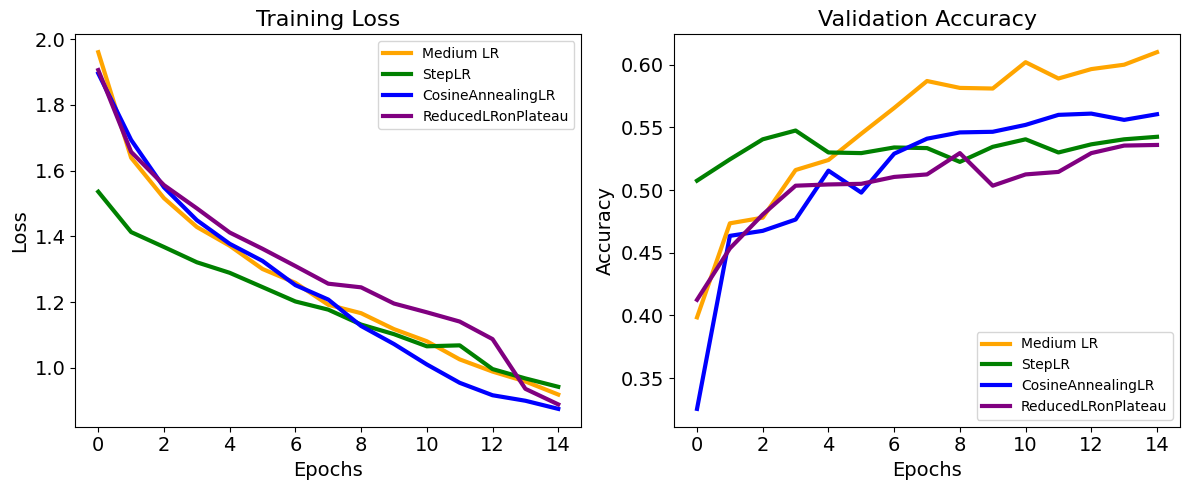

In [86]:
labels = ['Medium LR', 'StepLR', 'CosineAnnealingLR', 'ReducedLRonPlateau']
colors = ['orange', 'green', 'blue', 'purple']

training_curves_new = [history_constant, history_LR, history_cosine, history_plateau]

schedulers_helper_utils.plot_learning_curves(colors, labels, training_curves_new)